In [1]:
import sys
sys.path.append("..")

import numpy as np
from numpy.linalg import norm
from scipy.linalg import expm, block_diag

import matplotlib.pyplot as plt
from lunanav.constants import GM_MOON, R_MOON
from lunanav.sim.simulator import SimParams, SimResults, propagate, run_sim
from lunanav.plotting import debug_3d, plot_state_vector, plot_control_effort
from lunanav.sim.math.rigid_body import RigidBody, rigid_body_derivative
from lunanav.visualization import visualize_trajectory
from lunanav.sim.math.quaternion import angle_axis_to_q, mul, quat_apply, unit
from lunanav.estimation.ekf import EkfParams, ekf_predict#, ekf_update
from lunanav.sim.math.integration import rk4_func
import jax
import jax.numpy as jnp

# Sim!

In [2]:
def los_vectors():
    # M: sensor frame
    v1 = quat_apply(angle_axis_to_q(135, [-1,1,0], degrees=True), [0,0,1])
    v2 = quat_apply(angle_axis_to_q(135, [-1,-1,0], degrees=True), [0,0,1])
    v3 = quat_apply(angle_axis_to_q(135, [1,-1,0], degrees=True), [0,0,1])
    v4 = quat_apply(angle_axis_to_q(135, [1,1,0], degrees=True), [0,0,1])

    return v1, v2, v3, v4

In [3]:
lander = RigidBody(
    mass_kg = 100,
    I = np.eye(3)
)

dt = .1
t0 = 0
t_max = 50
nsteps = int(t_max//dt)

state0 = np.array([
    0,0, R_MOON, 
    0 ,0, 0,
    1,0,0,0, 
    0,0,0])


In [4]:
def control_fn(t, state):
    """Outputs inputs in body frame"""
    del state
    force_N = np.zeros(3)
    torque_Nm = np.zeros(3)

    # ----- Thrust -----
    if t < 5:
        force_N += [0,0,3e3]

    elif t < 25:
        force_N += [0,0,8e3]

    elif t < 80:
        force_N += [0,0,30e3]

    # ----- Torque -----

    if t < 6:
        torque_Nm += [0.007, 0, 0]
    elif t < 18:
        torque_Nm += [-0.005, 0, 0]
    elif t < 36:
        torque_Nm += [0.003, 0, 0]
    elif t < 54:
        torque_Nm += [-0.003, 0, 0]

    return force_N, torque_Nm


## Perfect measurements

In [5]:
sim = SimParams(state0, lander, dt, nsteps)
results = run_sim(state0, nsteps, dt, control_fn, sim)
n = results.nsteps

In [6]:
moon_offset =  np.tile([0,0,R_MOON,0,0,0,0,0,0,0,0,0,0], (n, 1))

other_vecs = {
    "names": ["LOS1", "LOS2", "LOS3", "LOS4"],
    "vecs": los_vectors(),
    "colors": ['green', 'green', 'green', 'green'],
    "scale": 1e3
}


In [7]:
if False:
    fig = visualize_trajectory(results.states - moon_offset, results.t, dt, title="Lunar Descent Trajectory with LOS Vectors")
    fig.show()

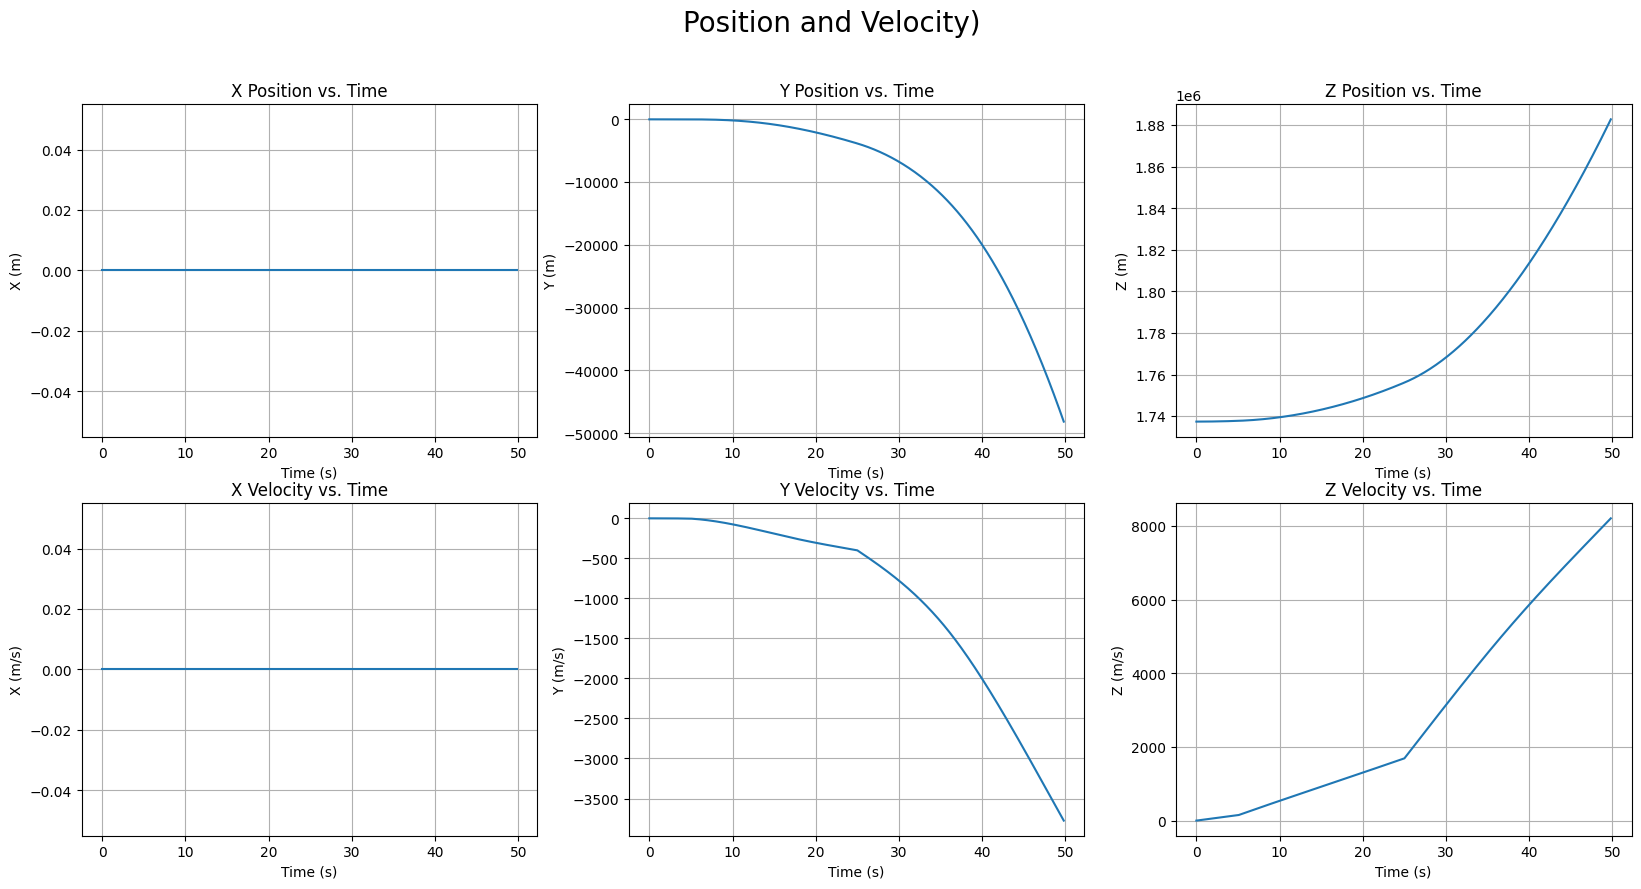

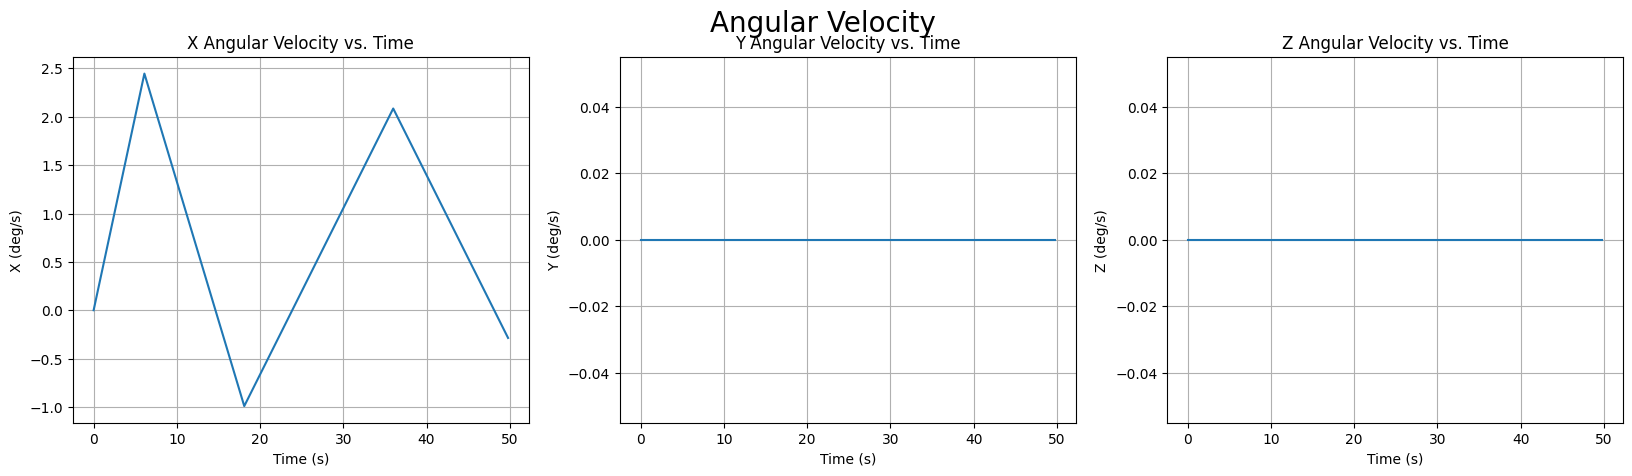

In [8]:
plot_state_vector(results.t, results.states[:,0:3], results.states[:,3:6], results.states[:,10:13])

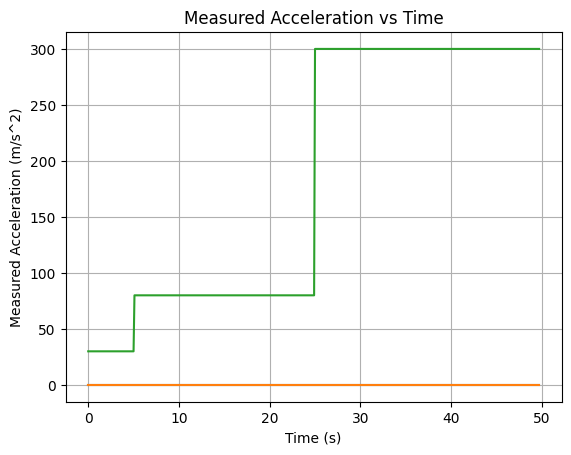

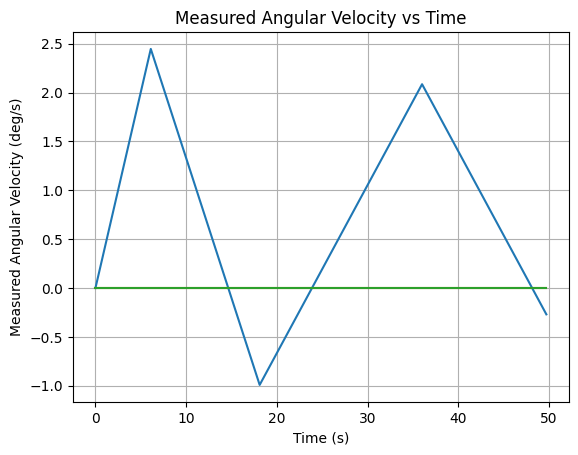

In [9]:
from lunanav.constants import RAD_TO_DEG

plt.plot(results.t[:-1], results.a_meas)
plt.xlabel("Time (s)")
plt.ylabel("Measured Acceleration (m/s^2)")
plt.title("Measured Acceleration vs Time")
plt.grid()
plt.show()

plt.plot(results.t[:-1], results.w_meas* RAD_TO_DEG)
plt.xlabel("Time (s)")
plt.ylabel("Measured Angular Velocity (deg/s)")
plt.title("Measured Angular Velocity vs Time")
plt.grid()
plt.show()

### EKF

In [10]:
# def linearize(f, s, u):
#     A,B = jax.jacobian(f, argnums=(0,1))(s, u)
#     return np.asarray(A), np.asarray(B)

# @jax.jit
# def ekf_deriv_wrapper(s, u):
#     q_B2I = unit(s[6:10])
#     force, torque = quat_apply(q_B2I, u[0:3]), u[3:6]
#     return rigid_body_derivative(0, s, force, torque, sim.body.mass_kg, sim.body.I)

# # fd = jax.jit(lambda s, u: rk4_func(0, sim.dt, s, ekf_deriv_wrapper(s,u)))
# fd = jax.jit(lambda s, u: rk4_func(0, sim.dt, s, lambda t, x: ekf_deriv_wrapper(x, u)))

# concatenated = np.concatenate(control_fn(0, state0))
# print("Concatenated Control Inputs:", concatenated)

# result = fd(state0, concatenated)
# print("Result from fd:", result)
# print(linearize(fd, state0, concatenated))


In [11]:
def Qd_from_accel_white(dt, sigma_a):

    # 2x2 covariance for (pos, vel) driven by white accel noise in ONE axis
    Q1 = np.array([
        [dt**3/3, dt**2/2],
        [dt**2/2, dt     ]
    ]) * (sigma_a**2)

    # Build block-diagonal structure for x, y, z axes.
    # At this point the order is [x, xd, y, yd, z, zd]
    Q_block = block_diag(Q1, Q1, Q1)

    # Reorder rows/cols to match OUR state order: [x, y, z, xd, yd, zd]
    # This permutation swaps (pos, vel) pairs into the correct structure.
    perm = np.array([0, 2, 4,   1, 3, 5])
    Q6 = Q_block[np.ix_(perm, perm)]

    return Q6

In [ ]:

# Q6 = Qd_from_accel_white(dt, sigma_a)
# Q = np.zeros((13,13))
# Q[0:6, 0:6] = Q6
# Q[6:10, 6:10] = np.eye(4) * 1e-6 # small process noise on quaternion to prevent filter divergence
# Q[10:13, 10:13] = np.eye(3) * 1e-6 # small process noise on angular velocity

Q = np.eye(13) * 1e-6 # for testing, use small process noise to see if EKF can track without it

# sigma_w = 0.01  # rad/s^2
# R = np.zeros((6,6))
# R[0:3,0:3] = np.eye(3) * (sigma_a**2)
# R[3:6,3:6] = np.eye(3) * (sigma_w**2)

In [49]:
# Make sensor noise
R_accel = np.eye(3)*0.01  # m/s^2
R_gyro = np.eye(3)*0.001  # rad/s^2

accel_meas = results.a_meas + np.random.multivariate_normal(np.zeros(3), R_accel, size=n-1)
gyro_meas = results.w_meas + np.random.multivariate_normal(np.zeros(3), R_gyro, size=n-1)

In [50]:


mu_arr = np.zeros((n, 13))
Sigma_arr = np.zeros((n, 13, 13))

mu_arr[0] = state0
Sigma_arr[0] = np.eye(13) * 1e-3

for i in range(n-1):
    # force, torque = control_fn(results.t[i], results.states[i])
    mu_pred, Sigma_pred = ekf_predict(mu_arr[i], Sigma_arr[i], accel_meas[i], gyro_meas[i], Q, sim)

    mu_arr[i+1] = mu_pred
    Sigma_arr[i+1] = Sigma_pred
    # For this test, we'll just use the true state as the "measurement" to isolate the prediction step.
    # z = results.states[i+1][0:6]  # True next state (pos and vel)
    # H = np.hstack([np.eye(6), np.zeros((6,4))])  # Measurement matrix to extract pos and vel
    # mu0, Sigma0 = ekf_update(mu_pred, Sigma_pred, z, H, R)

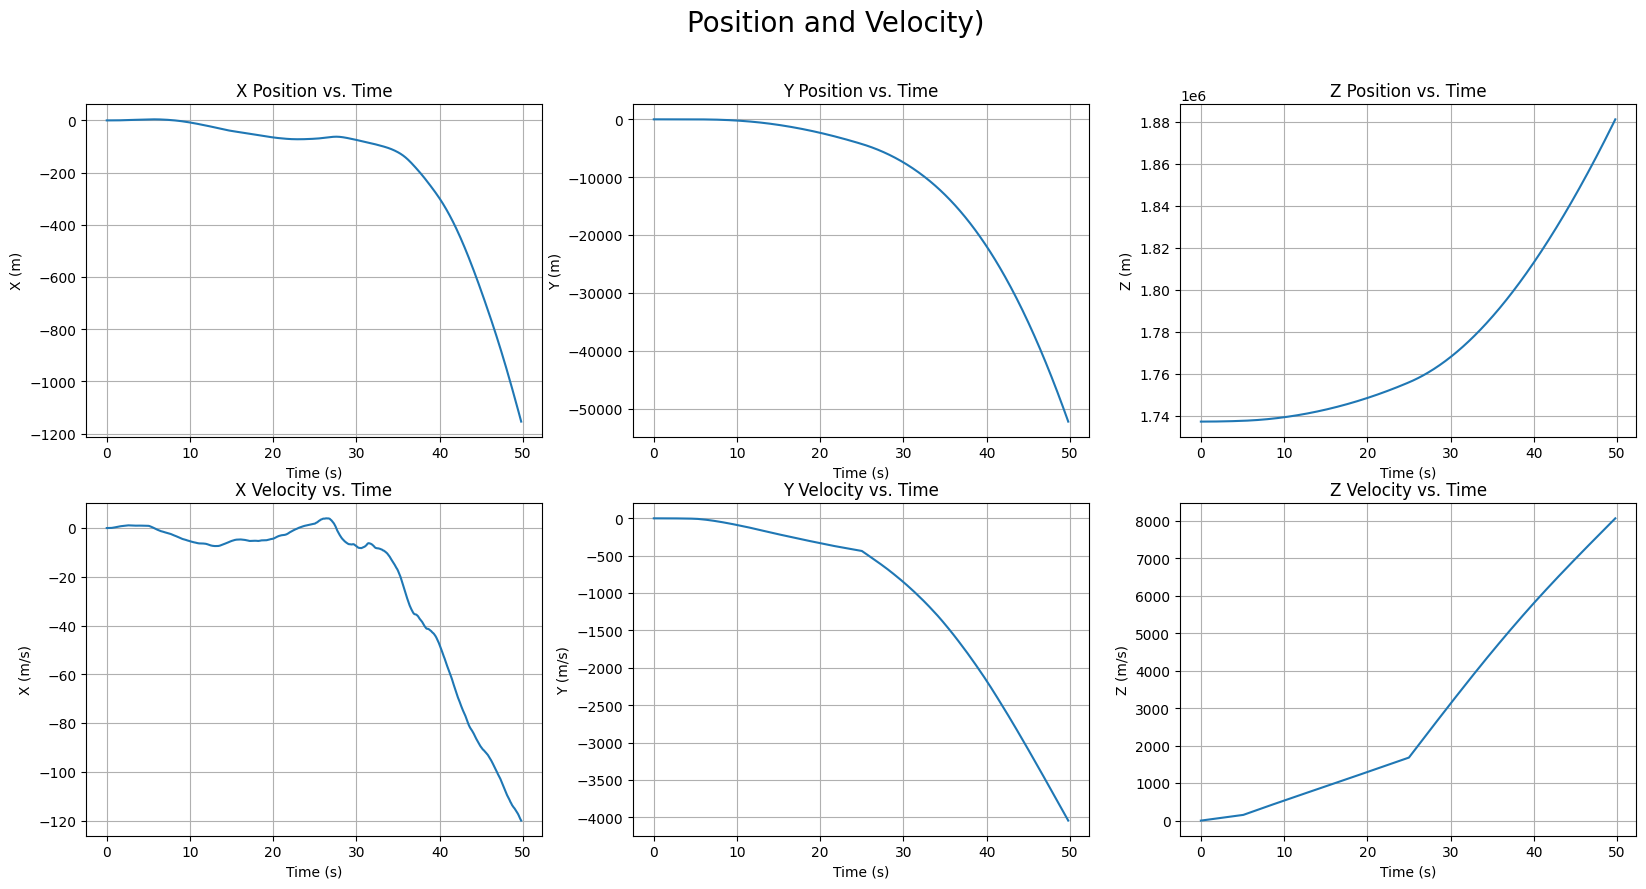

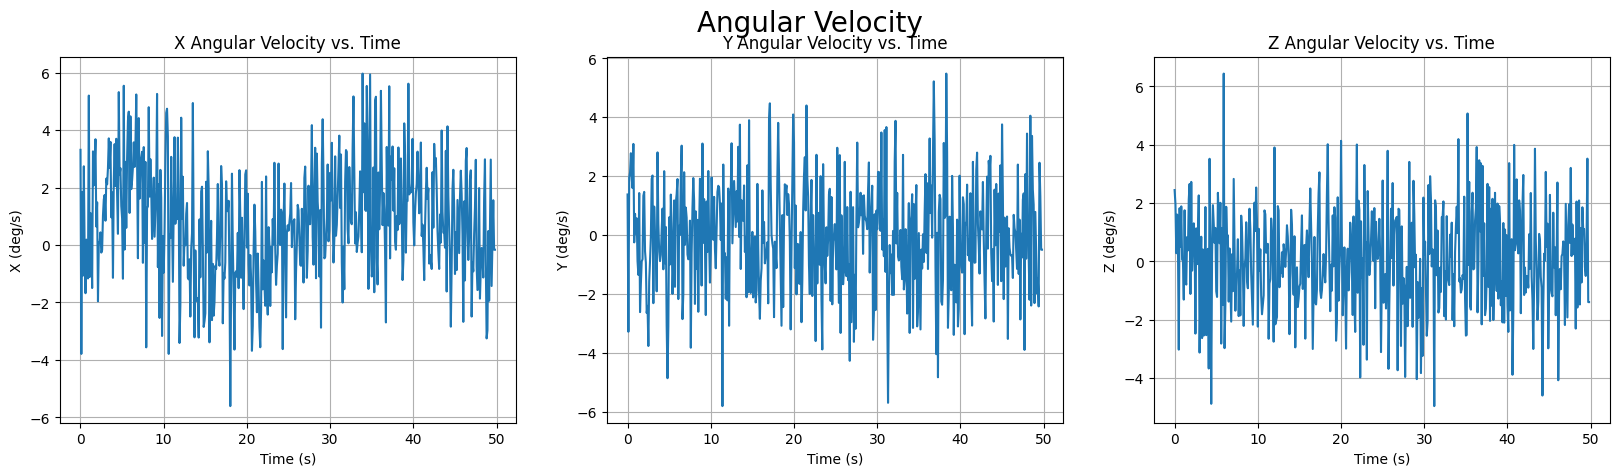

In [51]:
plot_state_vector(results.t, mu_arr[:,0:3], mu_arr[:,3:6], mu_arr[:,10:13])

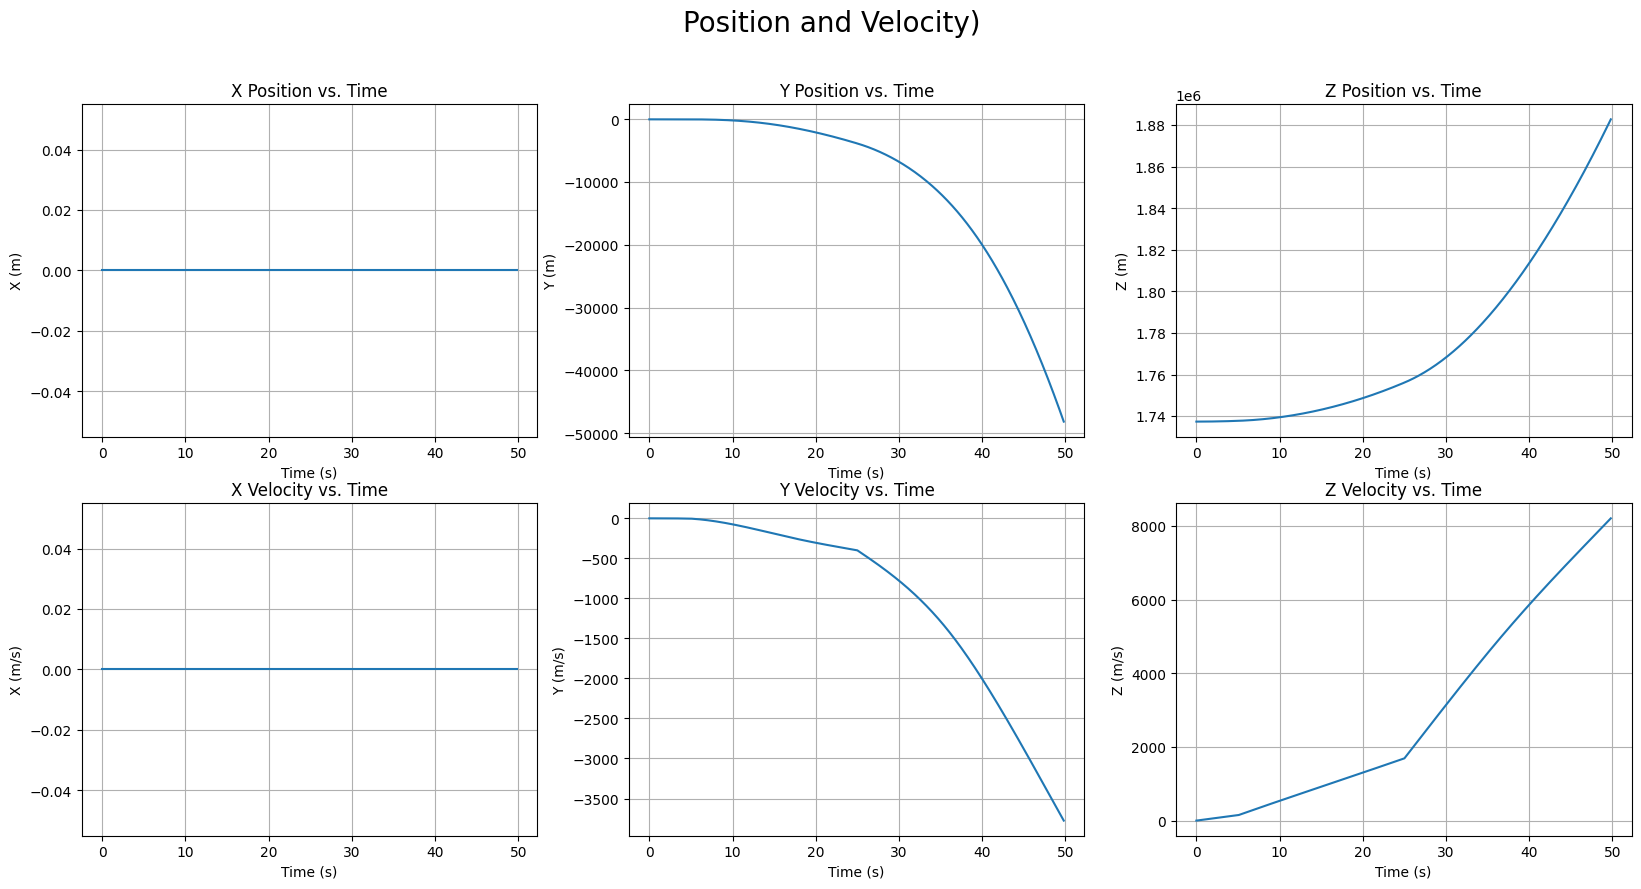

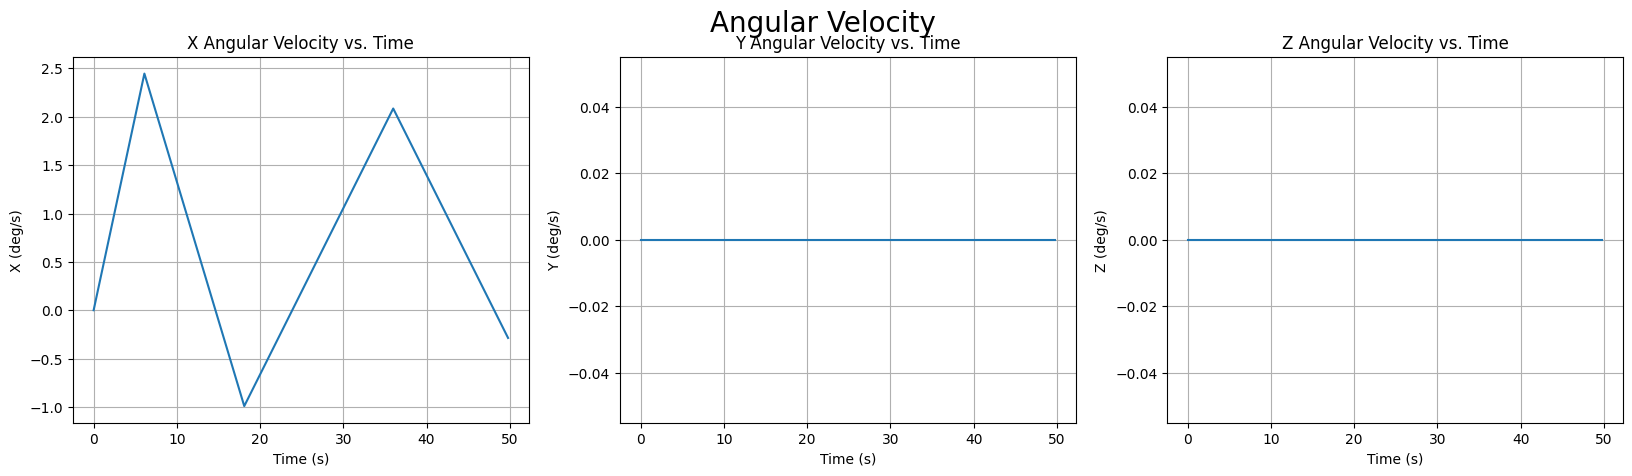

In [52]:
plot_state_vector(results.t, results.states[:,0:3], results.states[:,3:6], results.states[:,10:13])

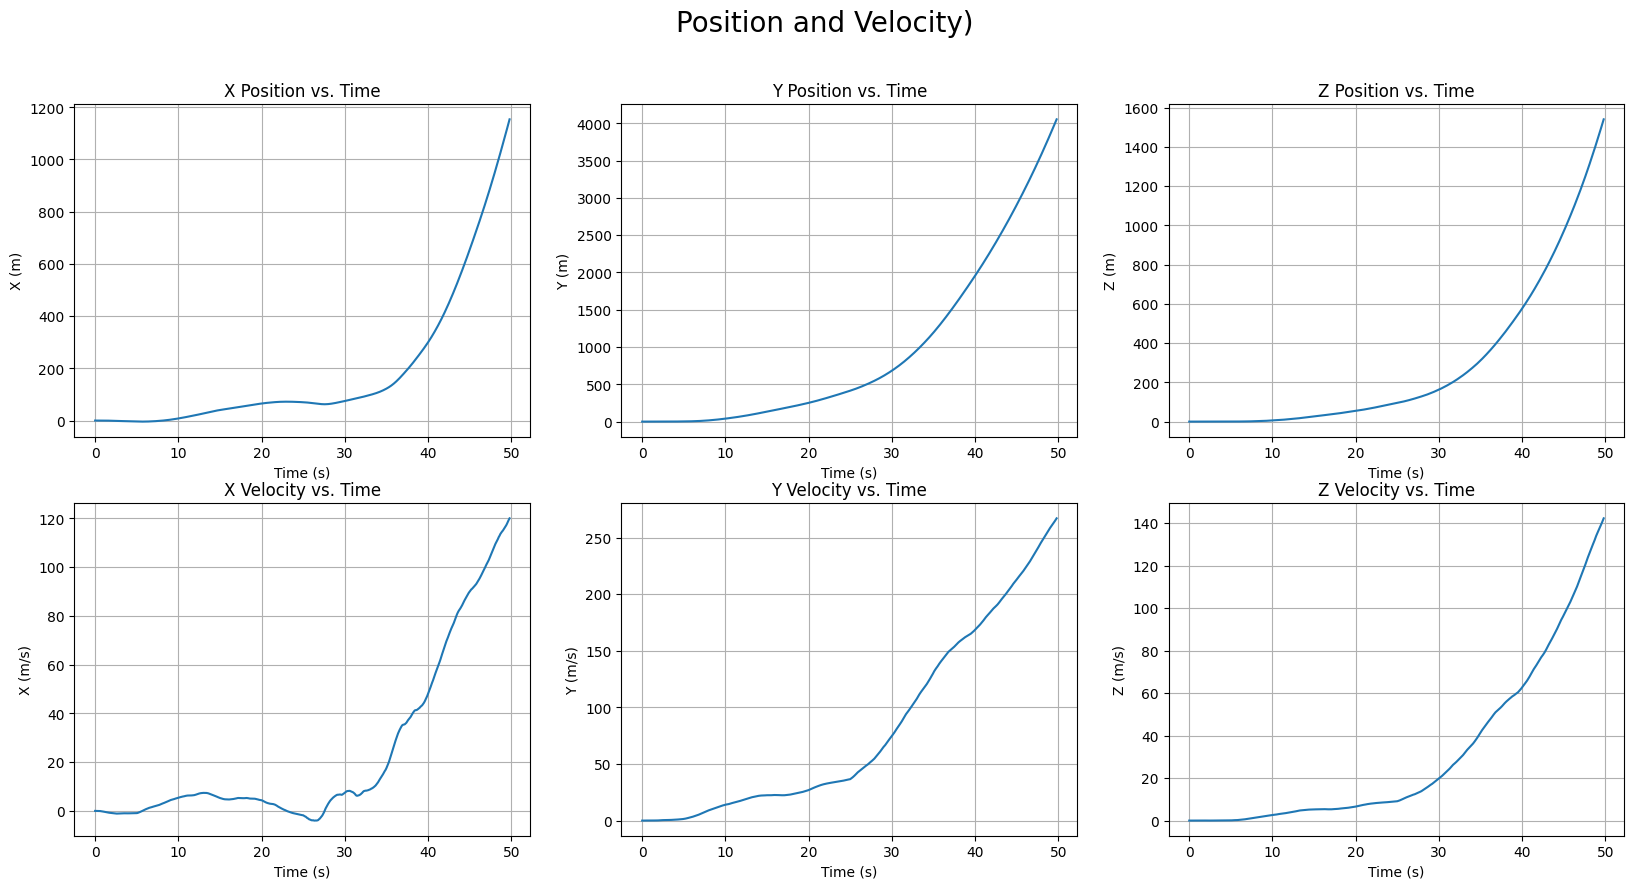

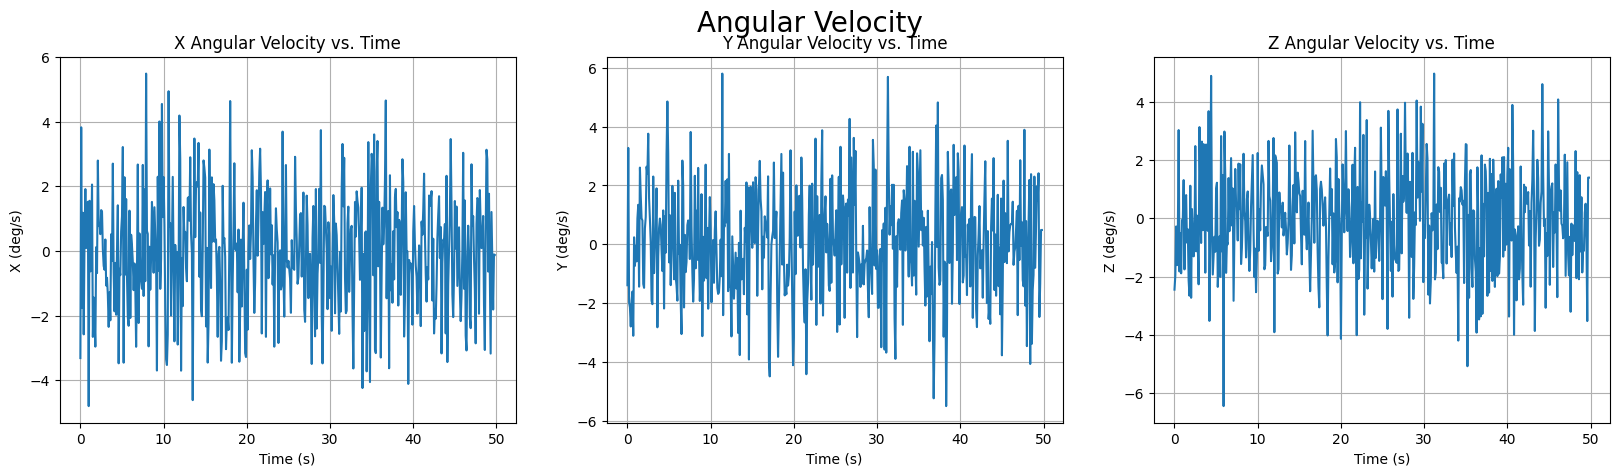

In [53]:
plot_state_vector(results.t, results.states[:,0:3] - mu_arr[:,0:3], results.states[:,3:6] - mu_arr[:,3:6], results.states[:,10:13] - mu_arr[:,10:13])